# COVID19 BIMCV Classifier
## CPSC483 CSUF

# Imports

In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import matplotlib.image as img
import xml.etree.ElementTree as ET

IMAGE_TYPE_IDENTIFIER = '00280004'

/home/ryan/workspace/school/cpsc483-project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Preprocessing

In [2]:
df = pd.read_csv("dataset/data.csv")
df['image_path'] = df['image_path'].apply(lambda x: "dataset/"+x)
df.head()

,Unnamed: 0,subject,image_path,image_type,session,label
0,0,sub-S330274,dataset/images/sub-S330274_ses-E61728_MONOCHRO...,MONOCHROME2,ses-E61728,True
1,1,sub-S329184,dataset/images/sub-S329184_ses-E68374_MONOCHRO...,MONOCHROME2,ses-E68374,True
2,2,sub-S329184,dataset/images/sub-S329184_ses-E59042_MONOCHRO...,MONOCHROME2,ses-E59042,True
3,3,sub-S330274,dataset/images/sub-S330274_ses-E61731_MONOCHRO...,MONOCHROME2,ses-E61731,True
4,4,sub-S330274,dataset/images/sub-S330274_ses-E61728_MONOCHRO...,MONOCHROME2,ses-E61728,True


In [3]:
df.reset_index(drop=True, inplace=True)
# Validate image paths in the DataFrame
valid_indices = []
problematic_image_paths = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Validating images in DataFrame"):
    img_path = os.path.relpath(row['image_path'], './')
    try:
        # Attempt to open the image and verify its integrity
        with Image.open(img_path) as pil_img:
            pil_img.verify() # Verify that it is an image
        valid_indices.append(idx)
    except Exception as e:
        problematic_image_paths.append((img_path, str(e)))
        # Optionally, remove the problematic file if it exists
        if os.path.exists(img_path):
            os.remove(img_path)

if problematic_image_paths:
    print(f"Found {len(problematic_image_paths)} problematic images. Filtering them out.")
    for path, error_msg in problematic_image_paths[:5]: # Print first 5 errors
        print(f"  {path}: {error_msg}")
    if len(problematic_image_paths) > 5:
        print("... (truncated)")
    df = df.loc[valid_indices].reset_index(drop=True)
    print(f"Filtered DataFrame to {len(df)} valid images.")
else:
    print("All images in DataFrame are valid.")

Validating images in DataFrame:   0%|          | 0/3723 [00:00<?, ?it/s]

Validating images in DataFrame: 100%|██████████| 3723/3723 [00:01<00:00, 3138.30it/s] 

Found 1533 problematic images. Filtering them out.
  dataset/images/sub-S330274_ses-E61728_MONOCHROME2.png: [Errno 2] No such file or directory: 'dataset/images/sub-S330274_ses-E61728_MONOCHROME2.png'
  dataset/images/sub-S329184_ses-E68374_MONOCHROME2.png: [Errno 2] No such file or directory: 'dataset/images/sub-S329184_ses-E68374_MONOCHROME2.png'
  dataset/images/sub-S329184_ses-E59042_MONOCHROME2.png: [Errno 2] No such file or directory: 'dataset/images/sub-S329184_ses-E59042_MONOCHROME2.png'
  dataset/images/sub-S330274_ses-E61731_MONOCHROME2.png: [Errno 2] No such file or directory: 'dataset/images/sub-S330274_ses-E61731_MONOCHROME2.png'
  dataset/images/sub-S330274_ses-E61728_MONOCHROME2.png: [Errno 2] No such file or directory: 'dataset/images/sub-S330274_ses-E61728_MONOCHROME2.png'
... (truncated)
Filtered DataFrame to 2190 valid images.


In [4]:
df.to_csv("data.csv")

# Preview Data

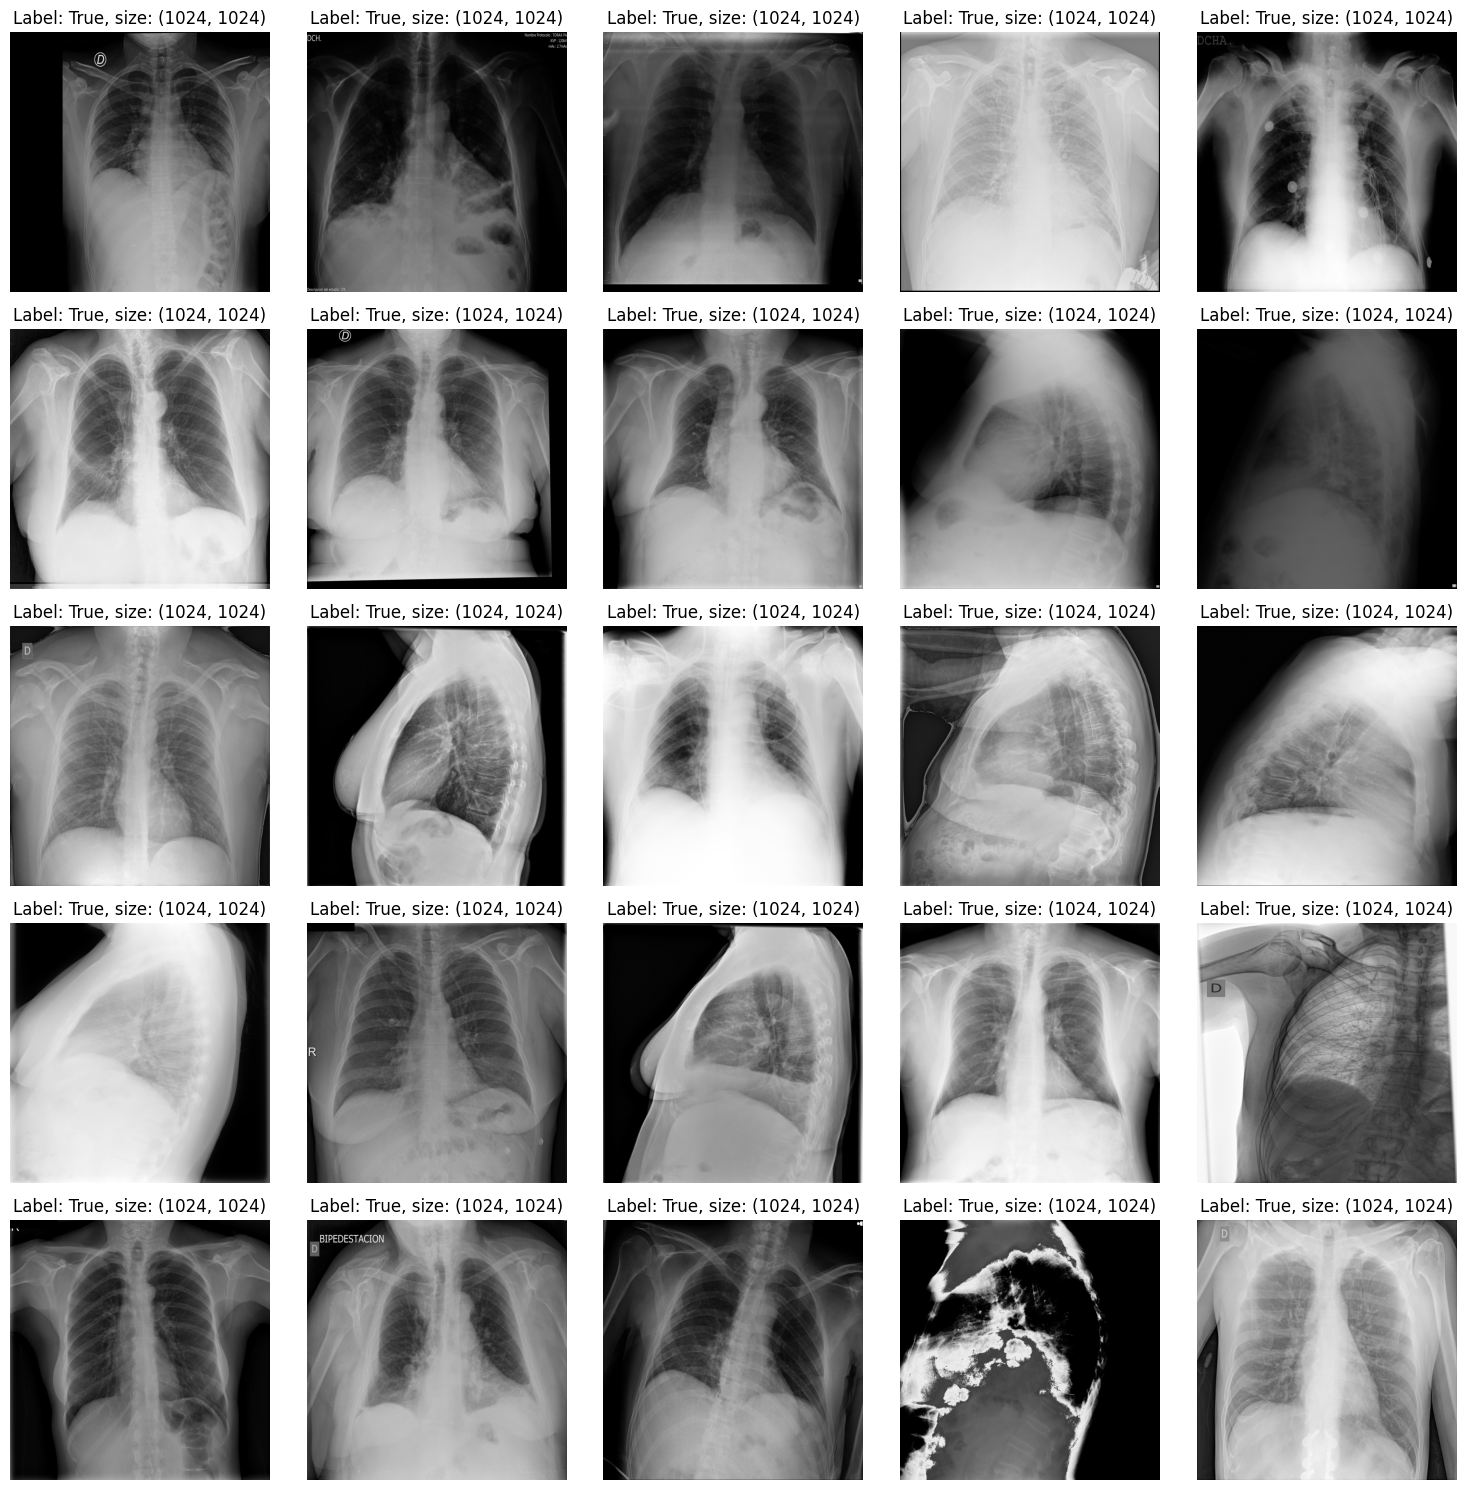

In [5]:
# preview 25 images from dataframe and plot them in a 5x5 grid
fig, axes = plt.subplots(5, 5, figsize=(15, 15))
for i, ax in enumerate(axes.flatten()):
    if i >= len(df):
        break
    image_path = df.sample(n=1).iloc[0]['image_path']
    image = img.imread(image_path)
    ax.imshow(image, cmap='gray')
    ax.set_title(f"Label: {df.iloc[i]['label']}, size: {image.shape}")
    ax.axis('off')
plt.tight_layout()
plt.show()

label
False    1282
True      908
Name: count, dtype: int64


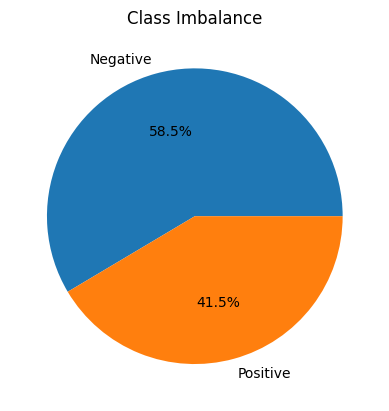

In [6]:
# get class imbalance
print(df['label'].value_counts())
num_neg = df['label'].value_counts()[False]
num_pos = df['label'].value_counts()[True]

plt.pie([num_neg, num_pos], labels=['Negative', 'Positive'], autopct='%1.1f%%')
plt.title('Class Imbalance')
plt.show()

# Dataset Loader

In [7]:
import cv2
from tqdm.auto import tqdm

class ChestXRayDatasetCLAHE(Dataset):
    def __init__(self, df, base_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.base_dir = base_dir
        self.transform = transform
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

        # self.images = []
        # self.labels = []

        # Preload all images into memory to speed up training
        # for idx in tqdm(range(len(self.df)), desc="Preloading images"):
        #     row = self.df.iloc[idx]
        #     rel_path = os.path.relpath(row['image_path'], './')
        #     img_path = os.path.join(self.base_dir, rel_path)

        #     # Load image in grayscale using OpenCV
        #     img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        #     if img is None:
        #         # Fallback if cv2 fails for some reason
        #         img = np.array(Image.open(img_path).convert('L'))

        #     # Handle MONOCHROME1 (inverted)
        #     if row['image_type'] == 'MONOCHROME1':
        #         img = cv2.bitwise_not(img)

        #     # Apply CLAHE to enhance contrast
        #     img = self.clahe.apply(img)

        #     # Convert back to PIL Image so torchvision transforms work
        #     img = Image.fromarray(img)

            # self.images.append(img)
            # self.labels.append(torch.tensor(int(row['label']), dtype=torch.float32))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        rel_path = os.path.relpath(row['image_path'], './')
        img_path = os.path.join(self.base_dir, rel_path)

        # Load image in grayscale using OpenCV
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            # Fallback if cv2 fails for some reason
            img = np.array(Image.open(img_path).convert('L'))

        # Handle MONOCHROME1 (inverted)
        if row['image_type'] == 'MONOCHROME1':
            img = cv2.bitwise_not(img)

        # Apply CLAHE to enhance contrast
        img = self.clahe.apply(img)

        # Convert back to PIL Image so torchvision transforms work
        img = Image.fromarray(img)# img = self.images[idx]

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(int(row['label']), dtype=torch.float32)
        return img, label

# Transforms for training and validation sets

In [8]:
train_transforms = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),                        # converts to [0, 1]
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # convert grayscale to 3 channels
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

val_transforms = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # convert grayscale to 3 channels
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Prepare training and validation sets

In [9]:
from sklearn.model_selection import StratifiedGroupKFold

# Ensure subjects are consistently typed
df['subject'] = df['subject'].astype(str)
df['label'] = df['label'].astype(int)

# First split: separate out the test set (10%)
sgkf_test = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
train_val_idx, test_idx = next(sgkf_test.split(df, df['label'], groups=df['subject']))

train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
test_df      = df.iloc[test_idx].reset_index(drop=True)

# Second split: separate the remaining 90% into Train (80% of total) and Val (10% of total)
sgkf_val = StratifiedGroupKFold(n_splits=9, shuffle=True, random_state=42)
train_idx, val_idx = next(sgkf_val.split(train_val_df, train_val_df['label'], groups=train_val_df['subject']))

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df   = train_val_df.iloc[val_idx].reset_index(drop=True)

print(f"Train: {len(train_df)} images ({train_df['label'].sum()} positive)")
print(f"Val:   {len(val_df)} images ({val_df['label'].sum()} positive)")
print(f"Test:  {len(test_df)} images ({test_df['label'].sum()} positive)")

Train: 1752 images (726 positive)
Val:   219 images (91 positive)
Test:  219 images (91 positive)


# Prepare Data Loaders

In [10]:
train_dataset = ChestXRayDatasetCLAHE(train_df, '.', transform=train_transforms)
val_dataset   = ChestXRayDatasetCLAHE(val_df,   '.', transform=val_transforms)
test_dataset  = ChestXRayDatasetCLAHE(test_df,  '.', transform=val_transforms)

In [11]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    # num_workers=2,
    # pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    # num_workers=2,
    # pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    # num_workers=2,
    # pin_memory=True
)

# Model

In [12]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # compute standard BCE loss with logits
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')

        # pt is the probability of the true class
        pt = torch.exp(-BCE_loss)

        # compute focal loss
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss

        if self.reduction == 'mean':
            return torch.mean(F_loss)
        elif self.reduction == 'sum':
            return torch.sum(F_loss)
        else:
            return F_loss

In [13]:
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

# Unfreeze the backbone to allow fine-tuning on our X-ray dataset
# for param in model.parameters():
    # param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(model.classifier.in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, 1),
)

# Training Structure

In [14]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu')
model     = model.to(device)

# criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([num_neg/num_pos], device=device))
criterion = FocalLoss(alpha=0.6, gamma=2, reduction='mean')

optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-4, weight_decay=1e-4)
# optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("device:", device)

def train_epoch(model, loader, optimizer, criterion, pbar):
    model.train()
    total_loss, correct = 0, 0
    total_samples = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
        pbar.update()
    return total_loss / len(loader), correct / len(loader.dataset)

def val_epoch(model, loader, criterion, pbar):
    model.eval()
    total_loss, correct = 0, 0
    total_samples = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device).unsqueeze(1)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            pbar.update()
    return total_loss / len(loader), correct / len(loader.dataset)

device: cuda


# Train

In [15]:
from colorama import Fore

NUM_EPOCHS = 20
PATIENCE = 4

# Gradual unfreezing schedule (epoch index -> list of layer names to unfreeze)
# unfreeze_schedule = {
#     2: ['layer4'],
#     4: ['layer3'],
#     6: ['layer2'],
# }
unfreeze_schedule = {
    2: ['denseblock4'],
    4: ['denseblock3'],
    6: ['denseblock2'],
}

epochs = []
best_val_loss = float('inf')
best_model_state = None
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1:02d}")

    # Check for gradual unfreezing
    if epoch in unfreeze_schedule:
        layers_to_unfreeze = unfreeze_schedule[epoch]
        print(f"--> Unfreezing layers: {', '.join(layers_to_unfreeze)}")
        for name, param in model.named_parameters():
            if any(name.startswith(layer_name) for layer_name in layers_to_unfreeze):
                param.requires_grad = True

    with tqdm(total=len(train_loader)+len(val_loader), desc=f"Epoch {epoch+1:02d}") as pbar:
      train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, pbar)
      val_loss, val_acc     = val_epoch(model, val_loader, criterion, pbar)

    scheduler.step(val_loss)
    epochs.append((train_loss, train_acc, val_loss, val_acc))
    print(f"Train - {Fore.RED}Loss: {train_loss:.4f}{Fore.RESET} | {Fore.GREEN}Acc: {train_acc:.3f}{Fore.RESET}\n"
          f"Val   - {Fore.RED}Loss: {val_loss:.4f}{Fore.RESET} | {Fore.GREEN}Acc: {val_acc:.3f}{Fore.RESET}\n"
          f"LR: {optimizer.param_groups[0]['lr']:.1e}\n")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Restore best model
if best_model_state:
    model.load_state_dict(best_model_state)
    print(f"\nRestored best model (val loss: {best_val_loss:.4f})")

Epoch 01


Epoch 01: 100%|██████████| 247/247 [01:01<00:00,  4.00it/s]


Train - Loss: 0.0979 | Acc: 0.628
Val   - Loss: 0.0905 | Acc: 0.658
LR: 1.0e-04

Epoch 02


Epoch 02: 100%|██████████| 247/247 [01:00<00:00,  4.06it/s]


Train - Loss: 0.0876 | Acc: 0.684
Val   - Loss: 0.0919 | Acc: 0.699
LR: 1.0e-04

Epoch 03
--> Unfreezing layers: denseblock4


...

Train - Loss: 0.0751 | Acc: 0.752
Val   - Loss: 0.0820 | Acc: 0.735
LR: 1.0e-04

Epoch 09


Epoch 09: 100%|██████████| 247/247 [01:00<00:00,  4.07it/s]


Train - Loss: 0.0772 | Acc: 0.742
Val   - Loss: 0.0878 | Acc: 0.694
LR: 1.0e-04

Epoch 10


Epoch 10: 100%|██████████| 247/247 [01:00<00:00,  4.08it/s]

Train - Loss: 0.0703 | Acc: 0.782
Val   - Loss: 0.0909 | Acc: 0.694
LR: 5.0e-05

Early stopping at epoch 10

Restored best model (val loss: 0.0820)


In [16]:
# Test best model
model.eval()
with tqdm(total=len(test_loader), desc="Testing") as pbar:
    test_loss, test_acc = val_epoch(model, test_loader, criterion, pbar)

print(f"\nFinal Test Results - {Fore.RED}Loss: {test_loss:.4f}{Fore.RESET} | {Fore.GREEN}Acc: {test_acc:.3f}{Fore.RESET}")

Testing: 100%|██████████| 28/28 [00:04<00:00,  6.46it/s]


Final Test Results - Loss: 0.0774 | Acc: 0.753


# Plotting Accuracy/Loss

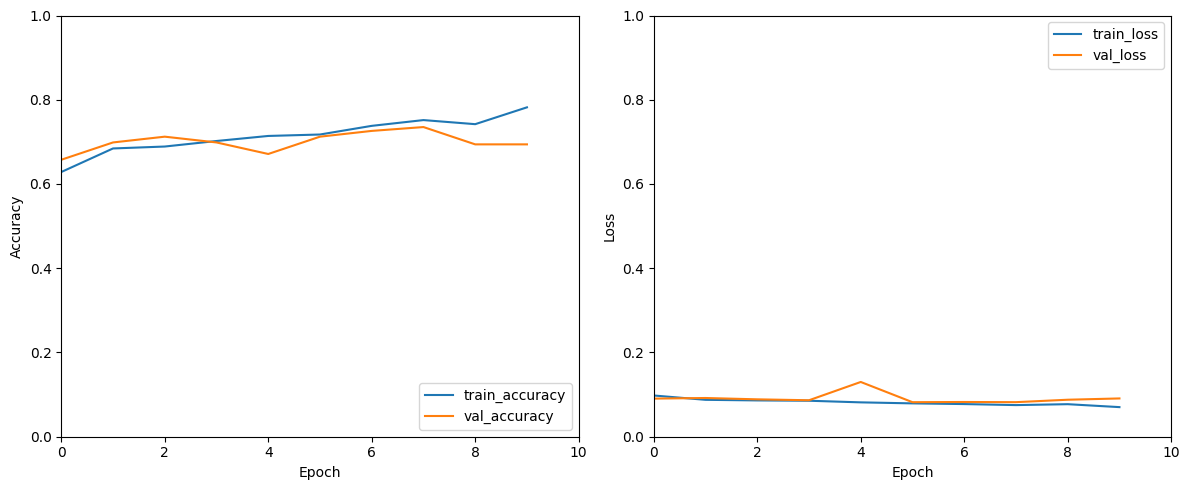

In [17]:
train_losses, train_accs, val_losses, val_accs = zip(*epochs)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(train_accs, label='train_accuracy')
axs[0].plot(val_accs, label='val_accuracy')
axs[0].set_ylim(0, 1)
axs[0].set_xlim(0, len(epochs))
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].legend(loc='lower right')

axs[1].plot(train_losses, label='train_loss')
axs[1].plot(val_losses, label='val_loss')
axs[1].set_ylim(0, 1)
axs[1].set_xlim(0, len(epochs))
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Evaluation Metrics

Classification Report on Test Set (Threshold: 0.5):
              precision    recall  f1-score   support

    Negative       0.79      0.79      0.79       128
    Positive       0.70      0.70      0.70        91

    accuracy                           0.75       219
   macro avg       0.75      0.75      0.75       219
weighted avg       0.75      0.75      0.75       219

AUC-ROC: 0.8381


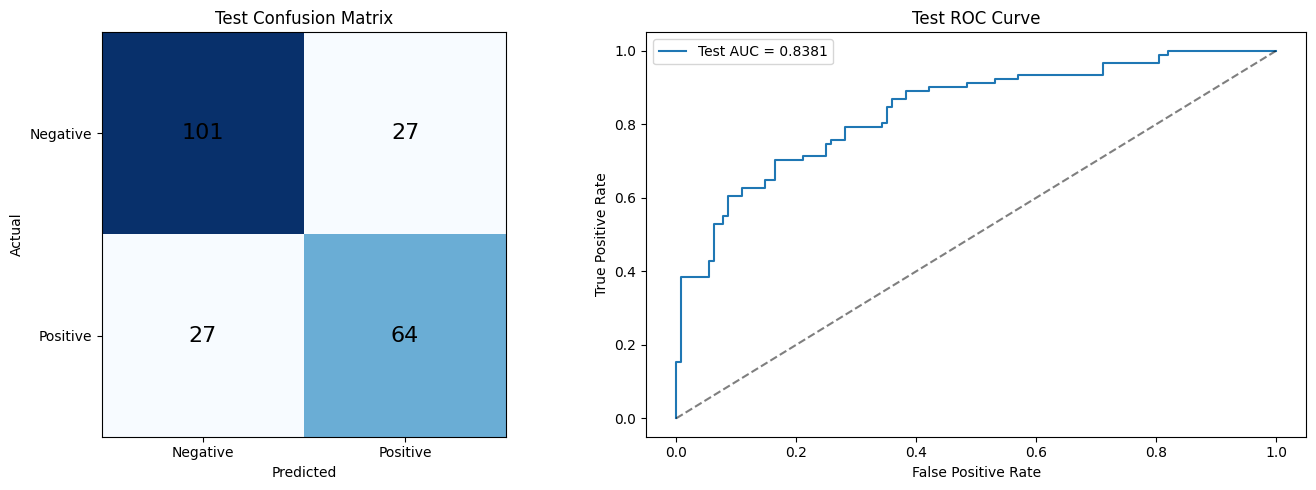

In [18]:
# Collect predictions on the TEST set
model.eval()
all_labels = []
all_probs = []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy().flatten())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

THRESHOLD = 0.5
all_preds = (all_probs > THRESHOLD).astype(int)

# Classification report (precision, recall, F1)
print(f"Classification Report on Test Set (Threshold: {THRESHOLD}):")
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

# AUC-ROC
auc = roc_auc_score(all_labels, all_probs)
print(f"AUC-ROC: {auc:.4f}")

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_labels, all_preds)
axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Test Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Negative', 'Positive'])
axes[0].set_yticklabels(['Negative', 'Positive'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16)

# ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, label=f'Test AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Test ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()